Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


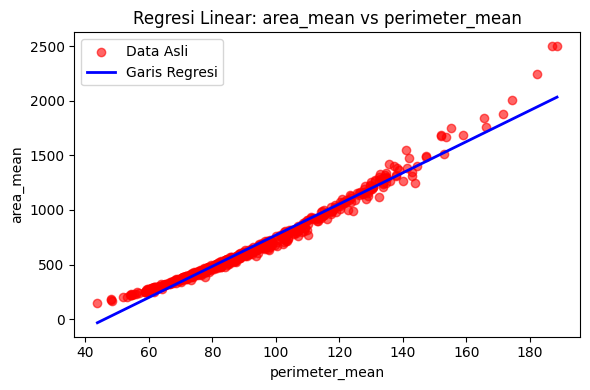

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from matplotlib.colors import ListedColormap

# 1. Mounting Google Drive (Colab)
from google.colab import drive

drive.mount('/content/drive')

# 2. Load dataset
file_path = '/content/drive/MyDrive/prakpola/data.csv'
df = pd.read_csv(file_path)
feature_names = df.columns[4:7]  # pilih tiga fitur, misal kolom ke-4,5,6
dx, dy = 0, 1                  # indeks fitur untuk plot 2D
x = df[feature_names[dx]].values.reshape(-1, 1)
y = df[feature_names[dy]].values

# ===== Regresi Linear =====
# 3. Buat dan latih model regresi linear (y ~ x)
lin_model = LinearRegression()
lin_model.fit(x, y)
y_pred = lin_model.predict(x)

# 4. Urutkan x untuk menggambar garis prediksi yang rapi
x_flat = x.flatten()
idx_sorted = np.argsort(x_flat)
x_sorted = x_flat[idx_sorted]
y_pred_sorted = y_pred[idx_sorted]

# 5. Plot scatter dan garis regresi
plt.figure(figsize=(6,4))
plt.scatter(x, y, color='red', alpha=0.6, label='Data Asli')
plt.plot(x_sorted, y_pred_sorted, color='blue', linewidth=2, label='Garis Regresi')
plt.title(f'Regresi Linear: {feature_names[dy]} vs {feature_names[dx]}')
plt.xlabel(feature_names[dx])
plt.ylabel(feature_names[dy])
plt.legend()
plt.tight_layout()
plt.show()

KASUS 2

KNN Accuracy: 0.9473684210526315
KNN Confusion Matrix:
 [[68  3]
 [ 3 40]]


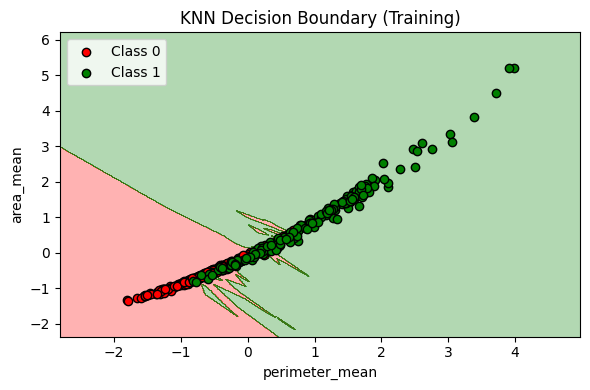

In [ ]:
# ===== Persiapan Klasifikasi =====
# 6. Ambil dua fitur untuk klasifikasi 2D
X = df[[feature_names[0], feature_names[1]]].values
y_class = df['diagnosis'].map({'M':1, 'B':0}).values

# 7. Split dan standarisasi
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42
)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# ===== KNN =====
knn = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
knn.fit(X_train_s, y_train)
y_pred_knn = knn.predict(X_test_s)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("KNN Confusion Matrix:\n", confusion_matrix(y_test, y_pred_knn))

# Plot decision boundary KNN (training)
x_set, y_set = X_train_s, y_train
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
    np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
)
plt.figure(figsize=(6,4))
plt.contourf(
    x1, x2,
    knn.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape),
    alpha=0.3, cmap=ListedColormap(('red','green'))
)
for i, label in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set==label,0], x_set[y_set==label,1],
        c=[ListedColormap(('red','green'))(i)], label=f"Class {label}", edgecolor='k'
    )
plt.title('KNN Decision Boundary (Training)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()


<ipython-input-11-6b07d09e71e4>:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


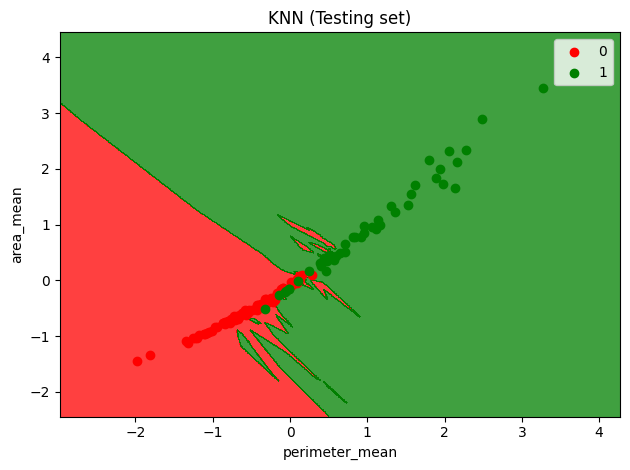

In [ ]:
# Visualisasi Decision Boundary - KNN (Testing set)
x_set, y_set = X_test_s, y_test
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(
    x1, x2,
    knn.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)
plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set == j, 0],
        x_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )
plt.title('KNN (Testing set)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()


Logistic Regression Accuracy: 0.9298245614035088
Logistic Regression Confusion Matrix:
 [[70  1]
 [ 7 36]]


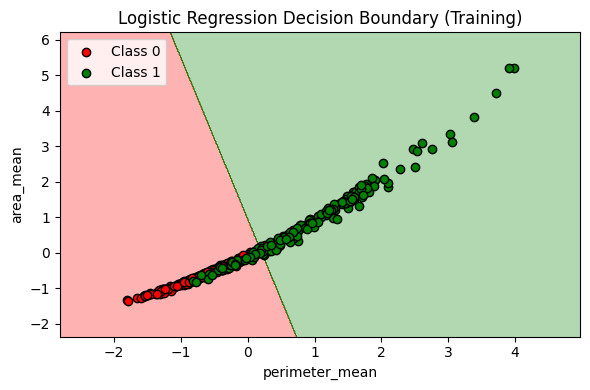

In [ ]:
# ===== Logistic Regression =====
log_model = LogisticRegression(max_iter=10000, random_state=0)
log_model.fit(X_train_s, y_train)
y_pred_log = log_model.predict(X_test_s)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))

# Decision boundary - Logistic Regression (Training)
x_set, y_set = X_train_s, y_train
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
    np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
)
plt.figure(figsize=(6,4))
plt.contourf(
    x1, x2,
    log_model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape),
    alpha=0.3, cmap=ListedColormap(('red','green'))
)
for i, label in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set==label,0], x_set[y_set==label,1],
        c=[ListedColormap(('red','green'))(i)], label=f"Class {label}", edgecolor='k'
    )
plt.title('Logistic Regression Decision Boundary (Training)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()




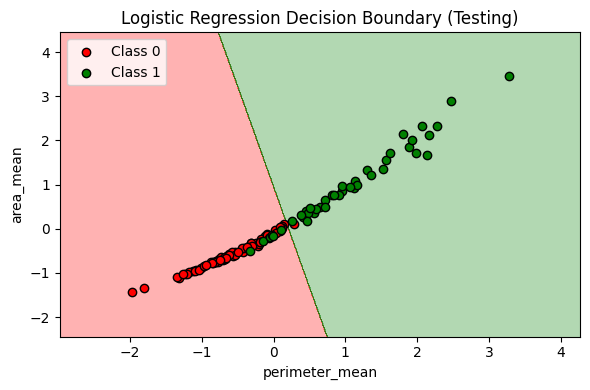

In [ ]:
# Decision boundary - Logistic Regression (Testing)
x_set, y_set = X_test_s, y_test
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
    np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
)
plt.figure(figsize=(6,4))
plt.contourf(
    x1, x2,
    log_model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape),
    alpha=0.3, cmap=ListedColormap(('red','green'))
)
for i, label in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set==label,0], x_set[y_set==label,1],
        c=[ListedColormap(('red','green'))(i)], label=f"Class {label}", edgecolor='k'
    )
plt.title('Logistic Regression Decision Boundary (Testing)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()


Decision Tree Accuracy: 0.8157894736842105
Decision Tree Confusion Matrix:
 [[60 11]
 [10 33]]


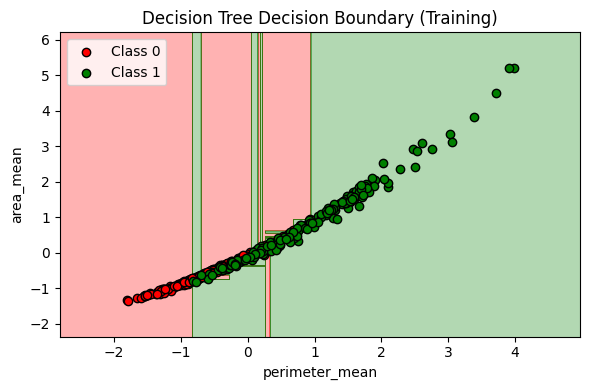

In [ ]:
# ===== Decision Tree =====
dt_model = DecisionTreeClassifier(random_state=0)
dt_model.fit(X_train_s, y_train)
y_pred_dt = dt_model.predict(X_test_s)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Decision Tree Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

# Decision boundary - Decision Tree (Training)
x_set, y_set = X_train_s, y_train
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:,0].min()-1, stop=x_set[:,0].max()+1, step=0.01),
    np.arange(start=x_set[:,1].min()-1, stop=x_set[:,1].max()+1, step=0.01)
)
plt.figure(figsize=(6,4))
plt.contourf(
    x1, x2,
    dt_model.predict(np.c_[x1.ravel(), x2.ravel()]).reshape(x1.shape),
    alpha=0.3, cmap=ListedColormap(('red','green'))
)
for i, label in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set==label,0], x_set[y_set==label,1],
        c=[ListedColormap(('red','green'))(i)], label=f"Class {label}", edgecolor='k'
    )
plt.title('Decision Tree Decision Boundary (Training)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()

<ipython-input-15-d9d38712a5cf>:16: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


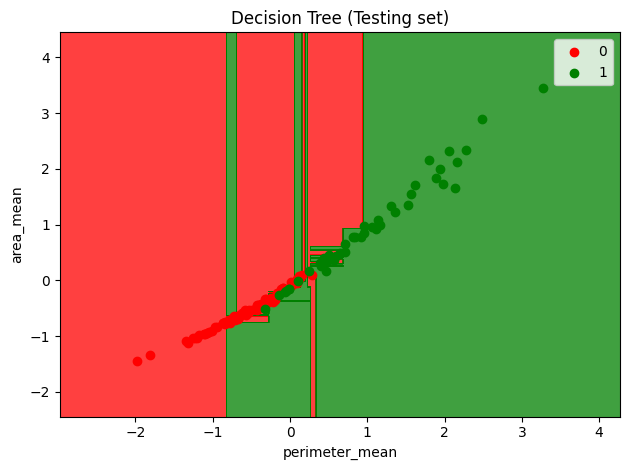

In [ ]:
# 10. Visualisasi Decision Boundary - Decision Tree (Testing set)
x_set, y_set = X_test_s, y_test
x1, x2 = np.meshgrid(
    np.arange(start=x_set[:, 0].min() - 1, stop=x_set[:, 0].max() + 1, step=0.01),
    np.arange(start=x_set[:, 1].min() - 1, stop=x_set[:, 1].max() + 1, step=0.01)
)
plt.contourf(
    x1, x2,
    dt_model.predict(np.array([x1.ravel(), x2.ravel()]).T).reshape(x1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)
plt.xlim(x1.min(), x1.max())
plt.ylim(x2.min(), x2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        x_set[y_set == j, 0],
        x_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )
plt.title('Decision Tree (Testing set)')
plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.legend()
plt.tight_layout()
plt.show()

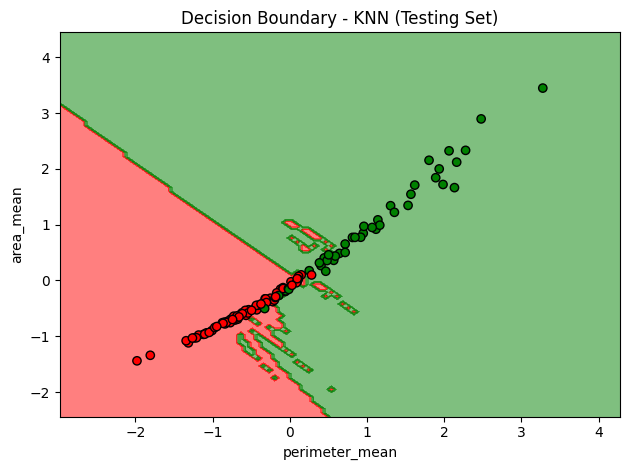

In [ ]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Asumsikan model KNN telah dilatih dan bernama 'knn_model'
# x_test dan y_test adalah data testing yang telah dinormalisasi

disp_knn = DecisionBoundaryDisplay.from_estimator(
    knn,
    X_test_s,
    response_method="predict",
    cmap=ListedColormap(['red', 'green']),
    alpha=0.5
)

# Plot data testing
disp_knn.ax_.scatter(
    X_test_s[:, 0],
    X_test_s[:, 1],
    c=y_test,
    cmap=ListedColormap(['red', 'green']),
    edgecolor='k'
)

disp_knn.ax_.set_title("Decision Boundary - KNN (Testing Set)")
disp_knn.ax_.set_xlabel(feature_names[0])
disp_knn.ax_.set_ylabel(feature_names[1])
plt.tight_layout()
plt.show()
